### This notebook computes "VCA6. Percentage variation rate of the Plant Factor" indicator for the 27 basins of IKI Project

Spanish: Tasa de variacion porcentual del Factor de Planta

**Created:** 12/2025 by Sophia Bakar (sbakar@rti.org) 
 
**Assumptions:** We assume that the potencia efectiva is the same because we only have this data for 2024. We use the earliest year available in the waterALLOC output database as the initial year and 2020 as the current year for the baseline scenario. COMIDs that do not have CHs are NaN. 
 
**Notes:** Some of the CHs in the shapefile and from the excel file lie outside of the boundaries of our subbasins.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import difflib
import unicodedata
import yaml
from pathlib import Path

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
# read in input data files
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
# wateralloc_db = master_path / "Modelacion" / "Grupos_Modelacion" / "Resultados" / "BalanceHidrico.sqlite"
hydraulic_head = master_path / "Indicadores" / "HydraulicHead.csv"
potencia_efectiva = master_path / "Indicadores" / "Capitulo-3-Generacion-Electrica-2024.xlsx"
ch_locations = master_path / "Indicadores" / "Datos_COES" / "COES_CH_EnOperacion.shp"

In [4]:
# set up indicator ID and get scenarios from database
IndID= 506 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
## check what scenarios are available in the WaterALLOC database
# Connect to WaterALLOC database
wateralloc_db = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\Resultados\BalanceHidrico.sqlite"
conn_wa = sqlite3.connect(wateralloc_db)

# Query available scenarios
scenarios_query = """
SELECT DISTINCT Scenario
FROM Scenarios
ORDER BY Scenario
"""

wa_scenarios_df = pd.read_sql_query(scenarios_query, conn_wa)

print("Available scenarios in WaterALLOC DB:")
for s in wa_scenarios_df["Scenario"]:
    print(f" - {s}")

# Close WaterALLOC database connection
conn_wa.close()

Available scenarios in WaterALLOC DB:
 - CC_CMIP6_45_2050
 - CC_CMIP6_85_2050
 - Linea_Base_2020
 - Linea_Base_2020_Embalses


In [6]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
head_df = pd.read_csv(hydraulic_head)
ch_gdf = gpd.read_file(ch_locations).to_crs('EPSG:32718')
potencia_df = pd.read_excel(potencia_efectiva)

In [7]:
# join subbasins with ch_gdf to get COMID for each ch location
subbasins_with_ch = gpd.sjoin(subbasins_gdf,ch_gdf,how='left',predicate='intersects').drop(columns='index_right')

In [8]:
# get monthly average flow for the intial and most recent year from WaterALLOC database 
# (Inflow + Local Flow - Demand)
# for now we are just doing this for the baseline scenario

scenario_name = 'Linea_Base_2020'

conn_wa = sqlite3.connect(wateralloc_db)

query_flow_yearly = """             
SELECT
    a.COMID,
    CAST(strftime('%Y', a.Fecha) AS INTEGER) AS Year,
    AVG(
        a.[Oferta Entrada]
      + a.[Oferta Local Sup]
      - a.[Dem Local Sup]
    ) AS Caudal_Medio_Anual
FROM "WAMSS_Balance por COMID (+Indice de estres)" AS a
JOIN WAMMS_RunsInfo AS b
    ON a.RunID = b.RunID
JOIN Scenarios AS c
    ON c.ScnID = b.ScnID
WHERE c.Scenario = ?
GROUP BY a.COMID, Year
"""

flow_yearly_df = pd.read_sql_query(
    query_flow_yearly,
    conn_wa,
    params=(scenario_name,)
)

conn_wa.close()

year_initial = 1990
year_current = 2020

# Keep only those two years
flow_if = flow_yearly_df[flow_yearly_df['Year'].isin([year_initial, year_current])].copy()

flow_if['Year_Type'] = np.where(flow_if['Year'] == year_initial,'init','current')

base_comids = subbasins_gdf[['COMID']].drop_duplicates()
year_types = pd.DataFrame({'Year_Type': ['init', 'current']})

# Cartesian product COMID x Year_Type
full_index = base_comids.merge(year_types, how='cross')

# Merge flow data onto full index
flow_if_full = full_index.merge(
    flow_if[['COMID', 'Year_Type', 'Caudal_Medio_Anual']],
    on=['COMID', 'Year_Type'],
    how='left'
)

# Pivot to wide format
flow_wide = (
    flow_if_full
    .pivot(index='COMID', columns='Year_Type', values='Caudal_Medio_Anual')
    .reset_index()
    .rename(columns={'init': 'Caudal_Medio_init', 'current': 'Caudal_Medio_current'})
)

# Assign scenario ID
flow_wide['ScnID_dynamic'] = 1

DatabaseError: Execution failed on sql '             
SELECT
    a.COMID,
    CAST(strftime('%Y', a.Fecha) AS INTEGER) AS Year,
    AVG(
        a.[Oferta Entrada]
      + a.[Oferta Local Sup]
      - a.[Dem Local Sup]
    ) AS Caudal_Medio_Anual
FROM "WAMSS_Balance por COMID (+Indice de estres)" AS a
JOIN WAMMS_RunsInfo AS b
    ON a.RunID = b.RunID
JOIN Scenarios AS c
    ON c.ScnID = b.ScnID
WHERE c.Scenario = ?
GROUP BY a.COMID, Year
': no such column: c.ScnID

In [9]:
# function to compute hydroelectric potential (PL) 
def compute_PL(Q, H, g=9.81):
    return g * Q * H

In [10]:
# Base COMIDs from subbasins
base_comids = subbasins_gdf[['COMID']].drop_duplicates()

# Only baseline scenario (ScnID_dynamic = 1)
base_scenarios = pd.DataFrame({'ScnID_dynamic': [1]})

# Cartesian product: every COMID gets baseline scenario
base_index = base_comids.merge(base_scenarios, how='cross')

# Merge flow (init + current) onto full COMID x scenario
pl_results = base_index.merge(flow_wide,on=['COMID', 'ScnID_dynamic'],how='left')

# Merge hydraulic head (scenario-independent)
pl_results = pl_results.merge(head_df,on='COMID',how='left')

pl_results['H_m'] = pl_results['H_m'].astype(float)

# Compute PL for initial and current year
pl_results['PL_W_init'] = np.where(pl_results[['Caudal_Medio_init', 'H_m']].notna().all(axis=1),compute_PL(pl_results['Caudal_Medio_init'], pl_results['H_m']), np.nan)

pl_results['PL_W_current'] = np.where(pl_results[['Caudal_Medio_current', 'H_m']].notna().all(axis=1),compute_PL(pl_results['Caudal_Medio_current'], pl_results['H_m']), np.nan)

# Keep desired columns
pl_results = pl_results[['COMID', 'ScnID_dynamic', 'Caudal_Medio_init', 'Caudal_Medio_current', 'H_m', 'PL_W_init', 'PL_W_current']]


In [11]:
# Subset where both PL_W_init and PL_W_current are available
pl_results[pl_results[['PL_W_init', 'PL_W_current']].notna().all(axis=1)]

,COMID,ScnID_dynamic,Caudal_Medio_init,Caudal_Medio_current,H_m,PL_W_init,PL_W_current
0,311153600,1,563.669167,3387.118333,10.770020,5.955384e+04,3.578622e+05
1,310832400,1,158041.964167,284347.184167,49.050049,7.604679e+07,1.368225e+08
2,310825700,1,162.320833,822.350833,1.500000,2.388551e+03,1.210089e+04
14,304273900,1,23213.443333,30402.193333,48.069992,1.094669e+07,1.433666e+07
15,304281100,1,14237.598333,17623.737500,33.839996,4.726461e+06,5.850559e+06
...,...,...,...,...,...,...,...
3527,311565900,1,39.730833,1203.287500,103.339844,4.027768e+04,1.219849e+06
3530,311565800,1,1216.643333,10862.404167,122.989746,1.467916e+06,1.310581e+07
3531,311584700,1,334.324167,5247.952500,62.680176,2.055734e+05,3.226927e+06
3532,311587000,1,153.031667,3212.835000,152.839844,2.294494e+05,4.817193e+06


In [12]:
subbasins_with_ch.columns

Index(['COMID', 'GRID_CODE', 'GRID_COUNT', 'PROD_UNIT', 'AREASQKM', 'Cuenca',
       'grupo_mod', 'IDDIST', 'NOMBDIST', 'geometry', 'NOMBRE DE',
       'NOMBRE D_1', 'TIPO DE CE', 'TIPO DE SI', 'ALTITUD', 'POTENCIAL',
       'POTENCIA_1', 'FUENTE DE', 'TIPO DE TU', 'SALTO(M)', 'SISTEMA EL',
       'CAUDAL(M3)', 'PUESTA EN', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO',
       'LATITUD', 'LONGITUD', 'FUENTE D_1', 'ESTADO'],
      dtype='object')

In [13]:
# Merge PL results with subbasins geometries 
subbasins_gdf_with_E = subbasins_with_ch.merge(pl_results,on='COMID',how='left')
# calculate the indicator values using the PL_W, and potencia efectivo
# convert PL_W to MW
subbasins_gdf_with_E['PL_I_MW'] = subbasins_gdf_with_E['PL_W_init'] / 1e6
subbasins_gdf_with_E['PL_C_MW'] = subbasins_gdf_with_E['PL_W_current'] / 1e6

# set up numerator and deonminator of the indicator
subbasins_gdf_with_E['Numerator'] = (subbasins_gdf_with_E['PL_I_MW'])/(subbasins_gdf_with_E['POTENCIA_1'])
subbasins_gdf_with_E['Denominator'] = ((subbasins_gdf_with_E['PL_C_MW'])/(subbasins_gdf_with_E['POTENCIA_1'])-1)

# calculate the indicator
subbasins_gdf_with_E['Delta_pct'] = subbasins_gdf_with_E['Numerator'] / subbasins_gdf_with_E['Denominator']

In [14]:
cols_to_drop = [
    'PROD_UNIT',
    'TIPO DE CE',
    'TIPO DE SI',
    'TIPO DE TU',
    'SISTEMA EL',
    'DEPARTAMEN',
    'PROVINCIA',
    'PUESTA EN'
]

subbasins_gdf_with_E = subbasins_gdf_with_E.drop(columns=cols_to_drop, errors='ignore')

In [16]:
mask = (
    subbasins_gdf_with_E['Caudal_Medio_init'].notna() &
    subbasins_gdf_with_E['POTENCIA_1'].notna()
)

comids_with_values = subbasins_gdf_with_E.loc[mask, 'COMID']

print(f"Number of COMIDs with Caudal_Medio_init and POTENCIA_1: {comids_with_values.nunique()}")
print(comids_with_values.sort_values().unique())

Number of COMIDs with Caudal_Medio_init and POTENCIA_1: 0
[]


In [11]:
# perform spatial join to get subbasin COMID for each CH
ch_gdf_with_pe = final_gdf[final_gdf.geometry.notna()].copy()

# ensure both GeoDataFrames are in the same CRS
final_gdf = final_gdf.to_crs(subbasins_gdf.crs)

# spatial join
subbasins_with_ch = gpd.sjoin(
    subbasins_gdf,
    ch_gdf_with_pe,
    how='left',
    predicate='intersects'
).drop(columns='index_right')

In [24]:
# format the potencia dataframe
potencia_df = potencia_df.copy()

# remove empty column
if 'Unnamed: 1' in potencia_df.columns:
    potencia_df = potencia_df.drop(columns=['Unnamed: 1'])

# set column headers
potencia_df.columns = [
    "Empresa",           
    "Central",         
    "Potencia_Instalada_MW",
    "Porc_PI",
    "Produccion_GWh",
    "Porc_PB"
]


# remove the first three rows (which are header info)
potencia_df = potencia_df.iloc[3:].reset_index(drop=True)

# drop rows that are completely NaN
potencia_df = potencia_df.dropna(how='all')

# drop rows that have any NaN
potencia_df = potencia_df.dropna(how='any')

In [25]:
# Function to remove accents from strings
def remove_accents(text):
    if pd.isna(text):
        return text
    # Normalize to NFD (decomposed form) and filter out combining characters
    return ''.join(c for c in unicodedata.normalize('NFD', str(text)) 
                if unicodedata.category(c) != 'Mn')

In [26]:
# Merge potencia with ch_gdf based on closest name matching

pot_df = potencia_df.copy()
ch_df = ch_gdf[['NOMBRE D_1', 'NOMBRE DE', 'geometry']].copy()

# Clean names for matching
pot_df['Central_clean'] = pot_df['Central'].str.lower().str.strip()
ch_df['NOMBRE_D1_clean'] = ch_df['NOMBRE D_1'].str.lower().str.strip()

# apply accent removal
pot_df['Central_clean'] = pot_df['Central_clean'].apply(remove_accents)
ch_df['NOMBRE_D1_clean'] = ch_df['NOMBRE_D1_clean'].apply(remove_accents)

matches = []
unmatched = []

for central in pot_df['Central_clean']:
    best = difflib.get_close_matches(
        central,
        ch_df['NOMBRE_D1_clean'],
        n=1,
        cutoff=0.7
    )
    if best:
        matches.append((central, best[0]))
    else:
        unmatched.append(central)

# Build match table
match_df = pd.DataFrame(matches, columns=['Central_clean', 'NOMBRE_D1_clean'])

# Merge potencia → matches
pot_matched = pot_df.merge(match_df, on='Central_clean', how='left')

# Merge with ch_gdf (geometry source)
final_gdf = ch_df.merge(
    pot_matched,
    on='NOMBRE_D1_clean',
    how='right'
)

# Keep only requested columns
#final_gdf = final_gdf[
#    list(potencia_df.columns) + ['NOMBRE D_1', 'NOMBRE DE', 'geometry']
#]

# Convert to GeoDataFrame
final_gdf = gpd.GeoDataFrame(final_gdf, geometry='geometry', crs=ch_gdf.crs)

# Report unmatched Centrals
if unmatched:
    print("\nCentrals not matched to ch_gdf:")
    for u in unmatched:
        print(f" - {u}")
else:
    print("\nAll Centrals matched successfully.")


Centrals not matched to ch_gdf:
 - c.h. antunez de mayolo
 - c.h. restitucion
 - c.h. cerro del aguila
 - c.h. el platanal
 - c.h. yaupi
 - c.t. kallpa
 - c.t. chilca
 - c.t. fenix
 - c.t. ventanilla
 - c.t. sto. domingo de los olleros
 - c.t. chilina
 - c.t. puerto bravo
 - c.t. nepi
 - c.t. santa rosa
 - c.t. aguaytia
 - c.t. recka
 - c.t. refineria talara
 - c.t. malacas 2
 - c.t. r.f. ilo
 - c.t. r.f. de generacion eten
 - c.t. r.f. malacas 3
 - c.t. r.f. iquitos nueva
 - c.t. rf pucallpa


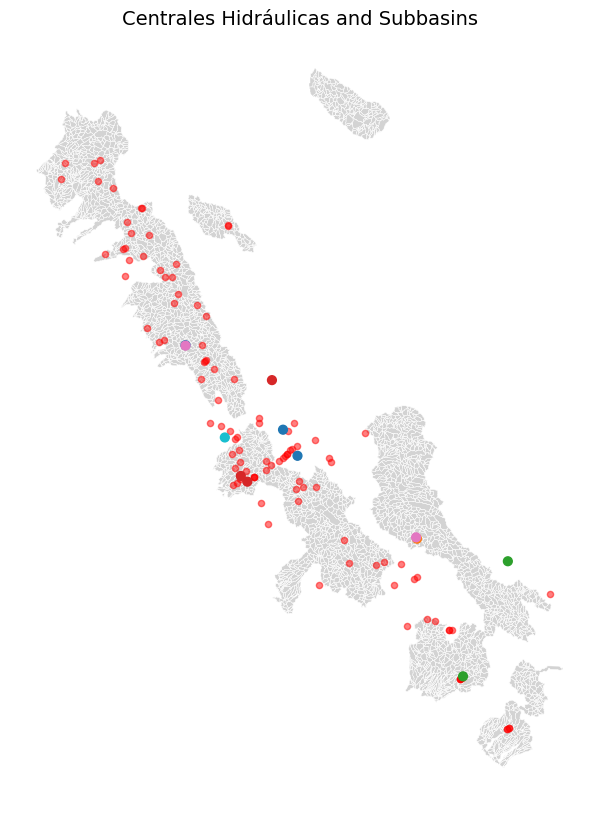

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

# plot subbasins
subbasins_gdf.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='white',
    linewidth=0.3
)

# plot Ch points before merging with potencia
ch_gdf.plot(
    ax=ax,
    color='red',
    markersize=20,
    alpha=0.5,
    label='CH Locations'
)

# plot CH points
final_gdf.plot(
    ax=ax,
    column='Empresa',   # or any categorical column
    legend=False,
    markersize=40
)

ax.set_title("Centrales Hidráulicas and Subbasins", fontsize=14)
ax.set_axis_off()

plt.show()

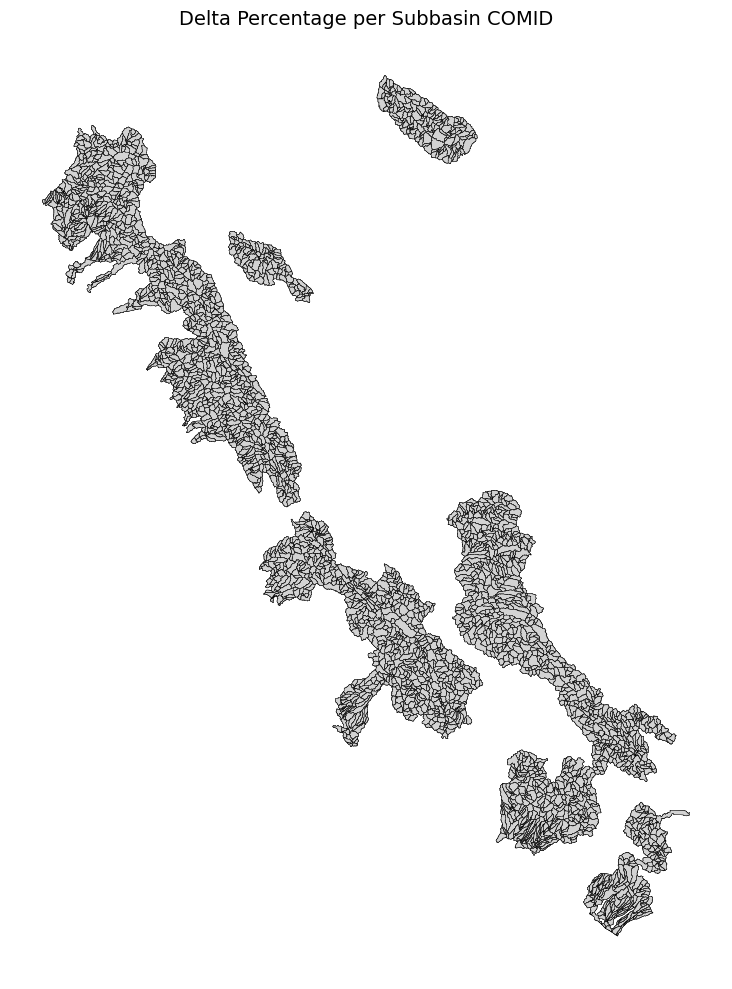

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot NaNs in light grey
subbasins_gdf_with_E.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.3)

# Plot valid values with scaled colorbar
data = subbasins_gdf_with_E[subbasins_gdf_with_E['Delta_pct'].notna()]

if not data.empty:
    vmin = data['Delta_pct'].quantile(0.02)
    vmax = data['Delta_pct'].quantile(0.98)
    data.plot(
        column='Delta_pct',
        cmap='OrRd',
        legend=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        edgecolor='black',
        linewidth=0.3
    )

ax.set_title(
    'Delta Percentage per Subbasin COMID',
    fontsize=14
)
ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# NEED TO ADD CODE HERE TO CATEGORIZE THE DELTA % VALUES

In [ ]:
# insert results into the database 
insert_data = subbasins_gdf_with_E
value_column = 'Delta_pct'

# Connect to SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for _, row in insert_data.iterrows():
    scn_id = row['ScnID_dynamic']
    comid = row['COMID']
    value = row[value_column]

    # Skip rows without scenario or value
    if pd.isna(scn_id) or pd.isna(value):
        continue

    rows_to_insert.append((
        int(scn_id),
        IndID,
        int(comid),
        float(value)
    ))

# Insert query
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [ ]:
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats_by_scenario = (
    pl_results
    .groupby('ScnID_dynamic')['PL_W']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== PL_W values by scenario ===")
print(value_stats_by_scenario)

df_check = pd.DataFrame(
    rows_to_insert,
    columns=['ScnID', 'IndID', 'COMID', 'Value']
)

duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])

In [ ]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()